In [2]:
# Full Imagenette2 preprocessing + ImageNet-pretrained ResNet fine-tuning

import json
import math
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, models, transforms

# -----------------------
# Config
# -----------------------
DATA_ROOT = Path("../../datasets/imagenette2").resolve()   # expects train/ and val/
OUTDIR = Path("./imagenette2_runs").resolve()
OUTDIR.mkdir(parents=True, exist_ok=True)

ARCH = "resnet50"
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 8
EPOCHS = 10
LR = 3e-4
WEIGHT_DECAY = 1e-4
SEED = 0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

train_dir = DATA_ROOT / "train"
val_dir = DATA_ROOT / "val"
if not train_dir.exists() or not val_dir.exists():
    raise FileNotFoundError(f"Expected {train_dir} and {val_dir} to exist.")

# -----------------------
# Preprocessing (canonical ImageNet/ResNet)
# -----------------------
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.6, 1.0),
        ratio=(3.0 / 4.0, 4.0 / 3.0),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(int(math.floor(IMG_SIZE * 256 / 224))),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# -----------------------
# Datasets / loaders
# -----------------------
train_ds = datasets.ImageFolder(str(train_dir), transform=train_transform)
val_ds   = datasets.ImageFolder(str(val_dir),   transform=val_transform)

NUM_CLASSES = len(train_ds.classes)
print("num classes:", NUM_CLASSES)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
)

# -----------------------
# Model (ImageNet-pretrained ResNet50) + fine-tunable head
# -----------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

device: cuda
num classes: 10


In [ ]:
# -----------------------
# Train / eval
# -----------------------
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.item()) * x.size(0)
        pred = logits.argmax(dim=1)
        correct += int((pred == y).sum().item())
        total += int(x.size(0))

    return total_loss / max(total, 1), correct / max(total, 1)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += float(loss.item()) * x.size(0)
        pred = logits.argmax(dim=1)
        correct += int((pred == y).sum().item())
        total += int(x.size(0))

    return total_loss / max(total, 1), correct / max(total, 1)

best_acc = -1.0
best_ckpt = OUTDIR / f"{ARCH}_imagenette2_best.pt"
last_ckpt = OUTDIR / f"{ARCH}_imagenette2_last.pt"

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {tr_loss:.4f}, acc {tr_acc:.4f} | "
        f"val loss {va_loss:.4f}, acc {va_acc:.4f}"
    )

    # Save last (state_dict)
    torch.save(model.state_dict(), last_ckpt)

    # Save best (state_dict)
    if va_acc > best_acc:
        best_acc = va_acc
        torch.save(model.state_dict(), best_ckpt)
        print(f"  ✓ saved best -> {best_ckpt} (val acc {best_acc:.4f})")

# -----------------------
# Save metadata for later IG work (class mapping, transforms info)
# -----------------------
meta = {
    "data_root": str(DATA_ROOT),
    "arch": ARCH,
    "img_size": IMG_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "classes": train_ds.classes,
    "class_to_idx": train_ds.class_to_idx,
    "best_checkpoint": str(best_ckpt),
    "last_checkpoint": str(last_ckpt),
    "imagenet_class_index_json": str(DATA_ROOT / "imagenet_class_index.json")
}

with open(OUTDIR / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved:")
print("  best:", best_ckpt)
print("  last:", last_ckpt)
print("  meta:", OUTDIR / "meta.json")


device: cuda
GT: tench
Pred: tench


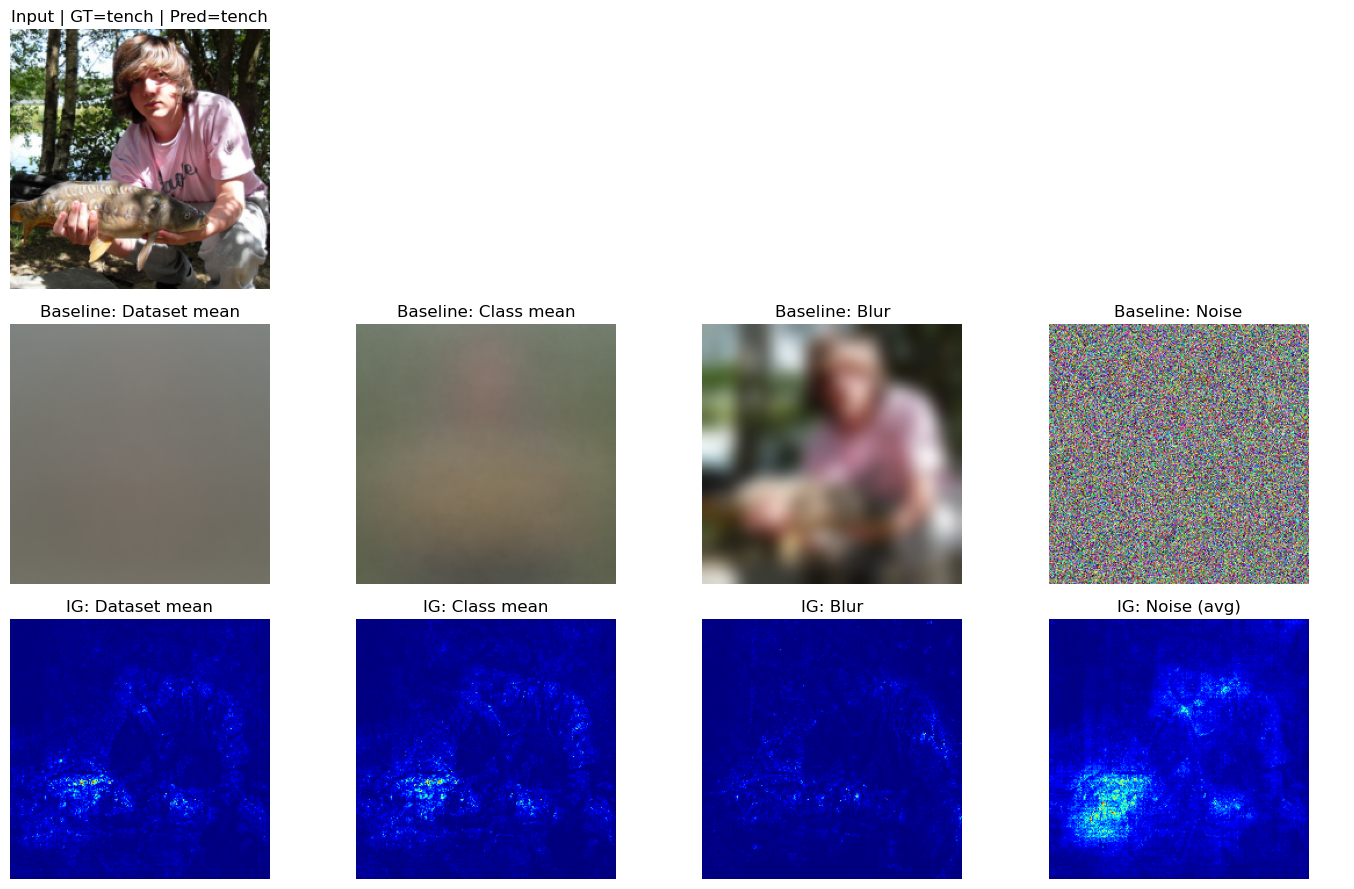

In [5]:
# ============================================================
# Integrated Gradients baseline experiments on Imagenette2
# ------------------------------------------------------------
# This script:
#   - loads a fine-tuned ResNet model,
#   - computes Integrated Gradients explanations,
#   - evaluates multiple baseline choices,
#   - renders baselines and IG attribution maps,
#   - displays class names using ImageNet synset metadata.
# ============================================================

import json
import math
from pathlib import Path

import torch
import torch.nn as nn

import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from torchvision.transforms import functional as TF


# ============================================================
# Configuration and device
# ============================================================

DATA_ROOT = Path("../../datasets/imagenette2")
RUN_DIR = Path("./imagenette2_runs")
META_PATH = RUN_DIR / "meta.json"
CKPT_PATH = RUN_DIR / "resnet50_imagenette2_best.pt"
FIG_DIR = RUN_DIR / "figs" / "ig_baselines"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

# Load training metadata
meta = json.loads(META_PATH.read_text())
IMG_SIZE = int(meta["img_size"])
IMAGENET_MEAN = tuple(meta["imagenet_mean"])
IMAGENET_STD = tuple(meta["imagenet_std"])

# Path to ImageNet synset metadata
CLASS_INDEX_PATH = Path(meta["imagenet_class_index_json"])


# ============================================================
# Synset-to-label mapping
# ============================================================

# Load ImageNet synset-to-label dictionary
imagenet_index = json.loads(CLASS_INDEX_PATH.read_text())
synset_to_label = {
    v[0]: v[1].replace("_", " ")
    for v in imagenet_index.values()
}


# ============================================================
# Transforms
# ============================================================

# Validation transform (normalized)
val_transform = transforms.Compose([
    transforms.Resize(int(math.floor(IMG_SIZE * 256 / 224))),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Validation transform without normalization (for mean-image computation)
val_transform_unnorm = transforms.Compose([
    transforms.Resize(int(math.floor(IMG_SIZE * 256 / 224))),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
])


# ============================================================
# Normalization utilities
# ============================================================

def unnormalize(x_norm: torch.Tensor) -> torch.Tensor:
    # Converts ImageNet-normalized tensor to [0,1] RGB
    mean = torch.tensor(IMAGENET_MEAN, device=x_norm.device).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=x_norm.device).view(3, 1, 1)
    return (x_norm * std + mean).clamp(0, 1)

def normalize(x01: torch.Tensor) -> torch.Tensor:
    # Converts [0,1] RGB tensor to ImageNet-normalized space
    mean = torch.tensor(IMAGENET_MEAN, device=x01.device).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=x01.device).view(3, 1, 1)
    return (x01 - mean) / std


# ============================================================
# Datasets
# ============================================================

# Validation dataset (normalized)
val_ds = datasets.ImageFolder(str(DATA_ROOT / "val"), transform=val_transform)

# Training dataset without normalization (used for mean baselines)
train_ds_unnorm = datasets.ImageFolder(
    str(DATA_ROOT / "train"),
    transform=val_transform_unnorm,
)

# Class index mappings
classes = val_ds.classes
idx_to_class = {v: k for k, v in val_ds.class_to_idx.items()}

def class_name_from_idx(idx: int) -> str:
    # Maps class index → synset → human-readable label
    syn = idx_to_class[int(idx)]
    return synset_to_label.get(syn, syn)


# ============================================================
# Model
# ============================================================

# Load ResNet architecture and trained weights
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(classes))
model.load_state_dict(torch.load(CKPT_PATH, map_location="cpu"))
model.eval().to(DEVICE)


# ============================================================
# Integrated Gradients
# ============================================================

def integrated_gradients(x, target, x_base, steps=64, batch_steps=16):
    # Computes Integrated Gradients using a Riemann-sum approximation
    x = x.to(DEVICE)
    x_base = x_base.to(DEVICE)

    delta = x - x_base
    alphas = torch.linspace(0.0, 1.0, steps + 1, device=DEVICE)[1:]

    grad_sum = torch.zeros_like(x)

    for i in range(0, len(alphas), batch_steps):
        a = alphas[i:i + batch_steps].view(-1, 1, 1, 1)
        xk = x_base + a * delta
        xk.requires_grad_(True)

        score = model(xk)[:, target].sum()
        grads = torch.autograd.grad(score, xk)[0]
        grad_sum += grads.mean(dim=0, keepdim=True).detach()

    return delta * grad_sum


def reduce_attr(ig):
    # Reduces channelwise IG to a single 2D map
    return ig[0].abs().sum(dim=0)


def normalize_map(m):
    # Normalizes attribution map to [0,1] for visualization
    m = m - m.min()
    return m / (m.max() + 1e-12)


# ============================================================
# Mean image computation
# ============================================================

@torch.no_grad()
def compute_mean_image(ds, class_idx=None):
    # Computes pixelwise mean image over dataset or class subset
    acc = torch.zeros(3, IMG_SIZE, IMG_SIZE)
    n = 0
    for x, y in ds:
        if class_idx is not None and y != class_idx:
            continue
        acc += x
        n += 1
    return (acc / n).clamp(0, 1)

DATASET_MEAN_01 = compute_mean_image(train_ds_unnorm)
CLASS_MEAN_CACHE = {}


# ============================================================
# Baselines
# ============================================================

def baseline_zero(x):
    # Zero baseline in normalized space
    return torch.zeros_like(x)

def baseline_dataset_mean(x):
    # Dataset mean baseline in normalized space
    return normalize(DATASET_MEAN_01.to(x.device))

def baseline_class_mean(x, cls):
    # Class-conditional mean baseline in normalized space
    if cls not in CLASS_MEAN_CACHE:
        CLASS_MEAN_CACHE[cls] = compute_mean_image(train_ds_unnorm, cls)
    return normalize(CLASS_MEAN_CACHE[cls].to(x.device))

def baseline_blur(x, k=31, s=7.0):
    # Gaussian-blurred version of the input
    return normalize(TF.gaussian_blur(unnormalize(x), [k, k], [s, s]))

def baseline_noise(x, std=0.25, seed=0):
    # Random noise baseline defined in pixel space
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    z = torch.randn_like(x)
    return normalize((0.5 + std * z).clamp(0, 1))


# ============================================================
# Example selection and scalarization
# ============================================================

IDX = 300
IG_STEPS = 64
NOISE_N = 8

# Load example
x_norm, y = val_ds[IDX]
x = x_norm.unsqueeze(0).to(DEVICE)

# Compute prediction for scalarization
with torch.no_grad():
    logits = model(x)
    pred = int(logits.argmax(dim=1).item())

target = pred

print("GT:", class_name_from_idx(int(y)))
print("Pred:", class_name_from_idx(target))


# ============================================================
# Baseline construction and IG computation
# ============================================================

baselines = [
    # ("Zero", baseline_zero(x_norm)),
    ("Dataset mean", baseline_dataset_mean(x_norm)),
    ("Class mean", baseline_class_mean(x_norm, target)),
    ("Blur", baseline_blur(x_norm)),
]

noise_bases = [baseline_noise(x_norm, seed=100 + k) for k in range(NOISE_N)]

baseline_imgs = []
ig_maps = []

for name, b in baselines:
    ig = integrated_gradients(x, target, b.unsqueeze(0), steps=IG_STEPS)
    baseline_imgs.append((name, unnormalize(b).cpu()))
    ig_maps.append((name, normalize_map(reduce_attr(ig).cpu())))

noise_igs = []
for b in noise_bases:
    ig = integrated_gradients(x, target, b.unsqueeze(0), steps=IG_STEPS)
    noise_igs.append(reduce_attr(ig).cpu())

baseline_imgs.append(("Noise", unnormalize(noise_bases[0]).cpu()))
ig_maps.append(("Noise (avg)", normalize_map(torch.stack(noise_igs).mean(dim=0))))


# ============================================================
# Visualization
# ============================================================

def show_img(ax, img, title):
    # Displays RGB image
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(title)
    ax.axis("off")

def show_heat(ax, heat, title):
    # Displays attribution heatmap
    ax.imshow(heat.numpy(), cmap="jet")
    ax.set_title(title)
    ax.axis("off")

n = len(baseline_imgs)
fig, axes = plt.subplots(3, n, figsize=(3.5 * n, 9))

# Input row
for j in range(n):
    axes[0, j].axis("off")

input_title = (
    f"Input | GT={class_name_from_idx(int(y))} "
    f"| Pred={class_name_from_idx(target)}"
)
show_img(axes[0, 0], unnormalize(x_norm).cpu(), input_title)

# Baseline row
for j, (name, img) in enumerate(baseline_imgs):
    show_img(axes[1, j], img, f"Baseline: {name}")

# IG row
for j, (name, heat) in enumerate(ig_maps):
    show_heat(axes[2, j], heat, f"IG: {name}")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/idx_{IDX}_ig_baselines.pdf", dpi=300)
plt.savefig(f"{FIG_DIR}/idx_{IDX}_ig_baselines.png", dpi=300)
plt.show()

In [10]:
# ============================================================
# Misclassified-image loop (max 20 plots) + save figures
# ------------------------------------------------------------
# This cell:
#   - constructs a list of misclassified validation indices,
#   - runs the baseline + IG pipeline for up to MAX_PLOTS images,
#   - saves one 3-row figure per image to RUN_DIR/figs/ig_misclassified,
#   - does not display figures in the notebook output.
# ============================================================

from pathlib import Path

MAX_PLOTS = 1000
MIS_MAX_SCAN = None
IG_STEPS = 64
NOISE_N = 8

# Output directory for figures
FIG_DIR = Path(RUN_DIR) / "figs" / "ig_misclassified"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------
# Collect indices of misclassified validation examples
# -----------------------

bad_idxs = []
n_scan = len(val_ds) if MIS_MAX_SCAN is None else min(len(val_ds), MIS_MAX_SCAN)

with torch.no_grad():
    for i in range(n_scan):
        x_norm_i, y_i = val_ds[i]
        x_i = x_norm_i.unsqueeze(0).to(DEVICE)
        pred_i = int(model(x_i).argmax(dim=1).item())
        if pred_i != int(y_i):
            bad_idxs.append(i)

if len(bad_idxs) == 0:
    raise RuntimeError("No misclassified examples found in scanned subset.")

# -----------------------
# Loop over misclassified examples and save plots
# -----------------------

import random
random.shuffle(bad_idxs)

for t, IDX in enumerate(bad_idxs[:MAX_PLOTS]):

    # Load image and label
    x_norm, y = val_ds[IDX]
    x = x_norm.unsqueeze(0).to(DEVICE)

    # Compute prediction for scalarization and display metadata
    with torch.no_grad():
        logits = model(x)
        probs = logits.softmax(dim=1)[0]
        pred = int(logits.argmax(dim=1).item())
        p_pred = float(probs[pred])
        p_gt = float(probs[int(y)])

    target = pred

    # Construct baseline tensors
    baselines = [
        # ("Zero", baseline_zero(x_norm)),
        ("Dataset mean", baseline_dataset_mean(x_norm)),
        ("Class mean", baseline_class_mean(x_norm, target)),
        ("Blur", baseline_blur(x_norm)),
    ]
    noise_bases = [baseline_noise(x_norm, seed=1000 * t + k) for k in range(NOISE_N)]

    # Compute IG maps and prepare baseline images
    baseline_imgs = []
    ig_maps = []

    for name, b in baselines:
        ig = integrated_gradients(x, target, b.unsqueeze(0), steps=IG_STEPS)
        baseline_imgs.append((name, unnormalize(b).detach().cpu()))
        ig_maps.append((name, normalize_map(reduce_attr(ig).detach().cpu())))

    noise_igs = []
    for b in noise_bases:
        ig = integrated_gradients(x, target, b.unsqueeze(0), steps=IG_STEPS)
        noise_igs.append(reduce_attr(ig).detach().cpu())

    baseline_imgs.append(("Noise", unnormalize(noise_bases[0]).detach().cpu()))
    ig_maps.append(("Noise (avg)", normalize_map(torch.stack(noise_igs, dim=0).mean(dim=0))))

    # Plot: row 1 input, row 2 baselines, row 3 IG maps (jet)
    n = len(baseline_imgs)
    fig, axes = plt.subplots(3, n, figsize=(3.5 * n, 9))

    for j in range(n):
        axes[0, j].axis("off")

    title = (
        f"Val idx {IDX} | GT={class_name_from_idx(int(y))} (p={p_gt:.3f}) "
        f"| Pred={class_name_from_idx(pred)} (p={p_pred:.3f})"
    )

    show_img(axes[0, 0], unnormalize(x_norm).detach().cpu(), title)

    for j, (name, img) in enumerate(baseline_imgs):
        show_img(axes[1, j], img, f"Baseline: {name}")

    for j, (name, heat) in enumerate(ig_maps):
        show_heat(axes[2, j], heat, f"IG: {name}")

    # Save and close figure (no notebook display)
    outpath = FIG_DIR / f"val_idx_{IDX:05d}_gt_{class_name_from_idx(int(y)).replace(' ', '-')}_pred_{class_name_from_idx(pred).replace(' ', '-')}.pdf"
    plt.tight_layout()
    fig.savefig(outpath, dpi=300)
    fig.savefig(outpath.with_suffix(".png"), dpi=300)
    plt.close(fig)


In [11]:
# ============================================================
# Within-method noise-seed sensitivity (IG) across noise levels
# ------------------------------------------------------------
# This cell:
#   - uses the random-noise baseline method with different seeds
#   - sweeps multiple noise standard deviations (noise levels)
#   - computes IG maps for each seed at each noise level
#   - builds pairwise matrices for: cosine similarity and L1 mean difference
#   - plots annotated seaborn heatmaps (2 decimals) with smaller text
#   - saves one PDF per noise level (no notebook display)
#
# Expected existing objects/functions:
#   model, DEVICE, val_ds, RUN_DIR
#   integrated_gradients, reduce_attr
#   baseline_noise (signature: baseline_noise(x_norm, std=..., seed=...))
#   class_name_from_idx (optional) OR idx_to_class (optional)
# ============================================================

from pathlib import Path
import json

import torch
import matplotlib.pyplot as plt
import seaborn as sns


# -----------------------
# Configuration
# -----------------------

IDX = 300
IG_STEPS = 64

NOISE_STD_LIST = [0.05, 0.10, 0.15, 0.20, 0.25]  # noise levels to sweep
NOISE_N = 8
NOISE_SEED0 = 100

ROUND = 2

# Figure/text sizing
FIGSIZE = (18, 8)          # width, height for the 1x2 panel
FONT_SCALE = 1.15          # global scaling for seaborn context
ANNOT_SIZE = 10            # smaller annotation text to prevent overlap

# Readability options
MASK_DIAGONAL = True
ROTATE_XTICKS = 45

FIG_DIR = Path(RUN_DIR) / "figs" / "ig_noise_within_method_sweep"
FIG_DIR.mkdir(parents=True, exist_ok=True)


# -----------------------
# Label helper
# -----------------------

def _class_name(idx: int) -> str:
    if "class_name_from_idx" in globals():
        return class_name_from_idx(idx)
    if "idx_to_class" in globals():
        return idx_to_class[int(idx)]
    return str(idx)


# -----------------------
# Metrics
# -----------------------

def _flat(m: torch.Tensor) -> torch.Tensor:
    return m.reshape(-1).float()

def cosine_sim(a: torch.Tensor, b: torch.Tensor) -> float:
    a = _flat(a); b = _flat(b)
    a = a / (a.norm(p=2) + 1e-12)
    b = b / (b.norm(p=2) + 1e-12)
    return float((a * b).sum().item())

def l1_mean_diff(a: torch.Tensor, b: torch.Tensor) -> float:
    a = _flat(a); b = _flat(b)
    return float((a - b).abs().mean().item())


# -----------------------
# Load example and fix scalarization to predicted class
# -----------------------

x_norm, y = val_ds[IDX]
x = x_norm.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    logits = model(x)
    probs = logits.softmax(dim=1)[0]
    pred = int(logits.argmax(dim=1).item())
    p_pred = float(probs[pred])
    p_gt = float(probs[int(y)])

target = pred


# -----------------------
# Seaborn defaults
# -----------------------

sns.set_style("white")
sns.set_context("talk", font_scale=FONT_SCALE)


# -----------------------
# Sweep noise levels
# -----------------------

labels = [f"s{NOISE_SEED0 + k}" for k in range(NOISE_N)]
mask = None
if MASK_DIAGONAL:
    mask = torch.eye(NOISE_N, dtype=torch.bool).numpy()

all_payload = {
    "val_idx": int(IDX),
    "gt": _class_name(int(y)),
    "pred": _class_name(int(target)),
    "p_gt": float(p_gt),
    "p_pred": float(p_pred),
    "ig_steps": int(IG_STEPS),
    "noise_n": int(NOISE_N),
    "seed0": int(NOISE_SEED0),
    "noise_std_list": [float(s) for s in NOISE_STD_LIST],
    "labels": labels,
    "files": [],
}

for std in NOISE_STD_LIST:

    # -----------------------
    # Compute IG maps for seeds at this noise level
    # -----------------------

    A = []
    for k in range(NOISE_N):
        seed = NOISE_SEED0 + k
        b = baseline_noise(x_norm, std=std, seed=seed)
        ig = integrated_gradients(x, target, b.unsqueeze(0), steps=IG_STEPS)
        A.append(reduce_attr(ig).detach().cpu())

    # -----------------------
    # Pairwise matrices
    # -----------------------

    M = NOISE_N
    cos_mat = torch.zeros(M, M)
    l1_mat  = torch.zeros(M, M)

    for i in range(M):
        for j in range(M):
            cos_mat[i, j] = cosine_sim(A[i], A[j])
            l1_mat[i, j]  = l1_mean_diff(A[i], A[j])

    # -----------------------
    # Plot 1x2 panel: cosine + L1
    # -----------------------

    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

    def _heat(ax, mat: torch.Tensor, title: str, center=None):
        sns.heatmap(
            mat.numpy(),
            ax=ax,
            annot=True,
            fmt=f".{ROUND}f",
            annot_kws={"size": ANNOT_SIZE},
            square=True,
            xticklabels=labels,
            yticklabels=labels,
            cmap="vlag",
            center=center,
            linewidths=0.5,
            cbar=True,
            cbar_kws={"shrink": 0.9},
            mask=mask,
        )
        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", labelrotation=ROTATE_XTICKS)

    _heat(axes[0], cos_mat, f"Cosine similarity (std={std:g})", center=0.0)
    _heat(axes[1], l1_mat,  f"L1 mean difference (std={std:g})", center=None)

    suptitle = (
        f"Within-method noise baseline sensitivity (IG) | val idx {IDX} | "
        f"GT={_class_name(int(y))} | Pred={_class_name(int(target))} | "
        f"noise std={std:g} | seeds {NOISE_SEED0}..{NOISE_SEED0 + NOISE_N - 1}"
    )
    fig.suptitle(suptitle, y=0.995)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    out_pdf = FIG_DIR / f"val_idx_{IDX:05d}_within_noise_seed_cos_l1_std{std:g}.pdf"
    fig.savefig(out_pdf, dpi=300)
    fig.savefig(out_pdf.with_suffix(".png"), dpi=300)
    plt.close(fig)

    # -----------------------
    # Save JSON per noise level
    # -----------------------

    out_json = FIG_DIR / f"val_idx_{IDX:05d}_within_noise_seed_cos_l1_std{std:g}.json"
    payload = {
        "val_idx": int(IDX),
        "noise_std": float(std),
        "labels": labels,
        "cosine_similarity": cos_mat.tolist(),
        "l1_mean_diff": l1_mat.tolist(),
        "figure_pdf": str(out_pdf),
    }
    out_json.write_text(json.dumps(payload, indent=2))

    all_payload["files"].append({
        "noise_std": float(std),
        "pdf": str(out_pdf),
        "json": str(out_json),
    })

# -----------------------
# Save sweep index JSON
# -----------------------

index_json = FIG_DIR / f"val_idx_{IDX:05d}_within_noise_seed_cos_l1_sweep_index.json"
index_json.write_text(json.dumps(all_payload, indent=2))


1742